In [3]:
import pandas as pd
import numpy as np

# Generating a messy 10-row dataset for your milestone challenge
challenge_data = {
    'Transaction_ID': [501, 502, 503, 503, 504, 505, 506, 507, 508, 509],
    'Customer_Name': ['Liam', 'Noah', 'Oliver', 'Oliver', 'Sophia', 'Ava', 'Emma', 'Mia', 'Lucas', 'Ella'],
    'Segment': ['Retail', 'Wholesale', 'Retail', 'Retail', 'Wholesale', 'Retail', 'Wholesale', 'Retail', 'Wholesale', 'Retail'],
    'Spent': ['$150', '$1,200', np.nan, np.nan, '$2,500', '$95', '$3,100', '$110', np.nan, '$180'],
    'Risk_Level': ['Low', 'High', 'Medium', 'Medium', 'High', 'Low', 'High', 'Low', 'Medium', 'Low']
}

df_challenge = pd.DataFrame(challenge_data)
print("--- 📌 The Milestone Challenge Dataset ---")
print(df_challenge)

--- 📌 The Milestone Challenge Dataset ---
   Transaction_ID Customer_Name    Segment   Spent Risk_Level
0             501          Liam     Retail    $150        Low
1             502          Noah  Wholesale  $1,200       High
2             503        Oliver     Retail     NaN     Medium
3             503        Oliver     Retail     NaN     Medium
4             504        Sophia  Wholesale  $2,500       High
5             505           Ava     Retail     $95        Low
6             506          Emma  Wholesale  $3,100       High
7             507           Mia     Retail    $110        Low
8             508         Lucas  Wholesale     NaN     Medium
9             509          Ella     Retail    $180        Low


In [4]:
df_challenge.drop_duplicates(inplace=True) #removing duplicates
print("\n--- After Removing Duplicates ---")
print(df_challenge)


--- After Removing Duplicates ---
   Transaction_ID Customer_Name    Segment   Spent Risk_Level
0             501          Liam     Retail    $150        Low
1             502          Noah  Wholesale  $1,200       High
2             503        Oliver     Retail     NaN     Medium
4             504        Sophia  Wholesale  $2,500       High
5             505           Ava     Retail     $95        Low
6             506          Emma  Wholesale  $3,100       High
7             507           Mia     Retail    $110        Low
8             508         Lucas  Wholesale     NaN     Medium
9             509          Ella     Retail    $180        Low


In [5]:
df_challenge['Spent'] = df_challenge['Spent'].str.replace('$', '').str.replace(',', '').astype(float)
print("\n--- After Cleaning Spent Column ---")
print(df_challenge)


--- After Cleaning Spent Column ---
   Transaction_ID Customer_Name    Segment   Spent Risk_Level
0             501          Liam     Retail   150.0        Low
1             502          Noah  Wholesale  1200.0       High
2             503        Oliver     Retail     NaN     Medium
4             504        Sophia  Wholesale  2500.0       High
5             505           Ava     Retail    95.0        Low
6             506          Emma  Wholesale  3100.0       High
7             507           Mia     Retail   110.0        Low
8             508         Lucas  Wholesale     NaN     Medium
9             509          Ella     Retail   180.0        Low


In [6]:
median_spent = df_challenge['Spent'].median()
df_challenge['Spent'] = df_challenge['Spent'].fillna(median_spent)
print("\n--- After Imputing Missing Spent ---")
print(df_challenge)


--- After Imputing Missing Spent ---
   Transaction_ID Customer_Name    Segment   Spent Risk_Level
0             501          Liam     Retail   150.0        Low
1             502          Noah  Wholesale  1200.0       High
2             503        Oliver     Retail   180.0     Medium
4             504        Sophia  Wholesale  2500.0       High
5             505           Ava     Retail    95.0        Low
6             506          Emma  Wholesale  3100.0       High
7             507           Mia     Retail   110.0        Low
8             508         Lucas  Wholesale   180.0     Medium
9             509          Ella     Retail   180.0        Low


In [7]:
risk_encoding = {'Low':1, 'Medium':2, 'High':3}
df_challenge['Risk_Level'] = df_challenge['Risk_Level'].map(risk_encoding)
print("\n--- After Encoding Risk_Level ---")
print(df_challenge)


--- After Encoding Risk_Level ---
   Transaction_ID Customer_Name    Segment   Spent  Risk_Level
0             501          Liam     Retail   150.0           1
1             502          Noah  Wholesale  1200.0           3
2             503        Oliver     Retail   180.0           2
4             504        Sophia  Wholesale  2500.0           3
5             505           Ava     Retail    95.0           1
6             506          Emma  Wholesale  3100.0           3
7             507           Mia     Retail   110.0           1
8             508         Lucas  Wholesale   180.0           2
9             509          Ella     Retail   180.0           1


In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Seed for reproducibility
np.random.seed(42)

# Generate synthetic player data
n_players = 100
ratings = np.random.normal(loc=1500, scale=150, size=n_players) # Bell curve data
hours_played = np.random.exponential(scale=3, size=n_players)    # Heavily skewed data

df_stats = pd.DataFrame({
    'Player_ID': range(1, n_players + 1),
    'Rating': ratings,
    'Hours_Logged': hours_played
})

print("--- Data Generated Successfully ---")
print(df_stats.head())

--- Data Generated Successfully ---
   Player_ID       Rating  Hours_Logged
0          1  1574.507123      1.620820
1          2  1479.260355      0.753502
2          3  1597.153281      0.383041
3          4  1728.454478      1.235726
4          5  1464.876994      8.589363


In [2]:
mean_rating = df_stats['Rating'].mean()
median_rating = df_stats['Rating'].median()

std_rating = df_stats['Rating'].std()
var_rating = df_stats['Rating'].var()

percentiles = df_stats['Rating'].quantile([0.25, 0.5, 0.75])

print("--- 📊 Rating Summary Metrics ---")
print(f"Mean Rating: {mean_rating:.2f}")
print(f"Median Rating: {median_rating:.2f}")
print(f"Standard Deviation: {std_rating:.2f}")
print(f"Variance (Std Dev squared): {var_rating:.2f}")
print("\n--- 📈 Percentiles ---")
print(percentiles)

--- 📊 Rating Summary Metrics ---
Mean Rating: 1484.42
Median Rating: 1480.96
Standard Deviation: 136.23
Variance (Std Dev squared): 18557.32

--- 📈 Percentiles ---
0.25    1409.864149
0.50    1480.956556
0.75    1560.892808
Name: Rating, dtype: float64


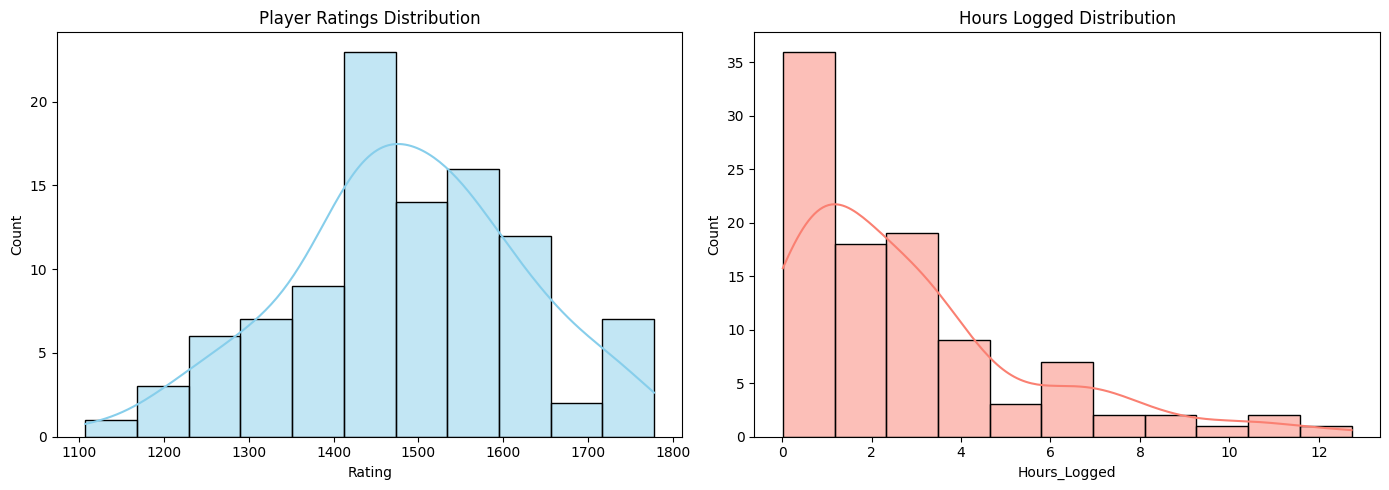

--- 🧬 Shapiro-Wilk Normality Test Results ---
Rating Column P-value: 0.65517
Hours Logged Column P-value: 0.00000


In [3]:
# 1. Create a side-by-side visual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Ratings Distribution
sns.histplot(df_stats['Rating'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Player Ratings Distribution')

# Plot 2: Hours Logged Distribution
sns.histplot(df_stats['Hours_Logged'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Hours Logged Distribution')

plt.tight_layout()
plt.show()

# 2. Run the Mathematical Shapiro-Wilk Normality Test
_, p_val_rating = stats.shapiro(df_stats['Rating'])
_, p_val_hours = stats.shapiro(df_stats['Hours_Logged'])

print("--- 🧬 Shapiro-Wilk Normality Test Results ---")
print(f"Rating Column P-value: {p_val_rating:.5f}")
print(f"Hours Logged Column P-value: {p_val_hours:.5f}")

In [4]:
import numpy as np
import scipy.stats as stats

# 1. Let's isolate our highly skewed Hours_Logged data
hours_data = df_stats['Hours_Logged']

# 2. Calculate the sample parameters
sample_mean = hours_data.mean()
sample_size = len(hours_data)
standard_error = stats.sem(hours_data) # Measures how much your sample mean varies from the true population mean

print("--- 📋 Sample Statistics ---")
print(f"Sample Mean Hours Logged: {sample_mean:.2f} hours")
print(f"Sample Size: {sample_size} players")
print(f"Standard Error of the Mean (SEM): {standard_error:.4f}")

# 3. Calculate the 95% Confidence Interval using the Student's t-distribution
confidence_level = 0.95
degrees_of_freedom = sample_size - 1

confidence_interval = stats.t.interval(
    confidence_level, 
    df=degrees_of_freedom, 
    loc=sample_mean, 
    scale=standard_error
)

print("\n--- 🔒 95% Confidence Interval Result ---")
print(f"We are 95% confident that the true average time played across the entire platform is between {confidence_interval[0]:.2f} and {confidence_interval[1]:.2f} hours.")

--- 📋 Sample Statistics ---
Sample Mean Hours Logged: 2.82 hours
Sample Size: 100 players
Standard Error of the Mean (SEM): 0.2717

--- 🔒 95% Confidence Interval Result ---
We are 95% confident that the true average time played across the entire platform is between 2.28 and 3.36 hours.


In [5]:
# 1. Simulate two separate player groups
np.random.seed(10)
optimized_players = np.random.normal(loc=1550, scale=130, size=50)   # Group A
unoptimized_players = np.random.normal(loc=1460, scale=140, size=50) # Group B

# 2. Run the Independent T-Test
t_stat, p_val = stats.ttest_ind(optimized_players, unoptimized_players, equal_var=False)

print("=== 📊 Independent T-Test Results ===")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.5f}")

if p_val < 0.05:
    print("Conclusion: Reject H0! The optimization has a statistically significant impact on ratings.")
else:
    print("Conclusion: Fail to reject H0. The difference could easily be random noise.")

=== 📊 Independent T-Test Results ===
T-statistic: 3.5994
P-value: 0.00051
Conclusion: Reject H0! The optimization has a statistically significant impact on ratings.


In [6]:
# Reaction times in milliseconds for the exact same 5 players
reaction_before = [240, 255, 230, 270, 225]
reaction_after  = [215, 230, 210, 245, 205] # Lower numbers mean faster reactions!

# Run the Paired T-Test
t_stat_paired, p_val_paired = stats.ttest_rel(reaction_before, reaction_after)

print("=== ⏱️ Paired T-Test Results ===")
print(f"T-statistic: {t_stat_paired:.4f}")
print(f"P-value: {p_val_paired:.5f}")

if p_val_paired < 0.05:
    print("Conclusion: Reject H0! The warm-up routine significantly reduces reaction time.")
else:
    print("Conclusion: Fail to reject H0. No definitive proof that the warm-up helped.")

=== ⏱️ Paired T-Test Results ===
T-statistic: 18.7794
P-value: 0.00005
Conclusion: Reject H0! The warm-up routine significantly reduces reaction time.


In [7]:
import pandas as pd

# 1. Create a contingency table of raw counts
# Rows: Preferred Style | Columns: Chosen Pieces
# Example: 30 players who play White prefer an Aggressive style
data_matrix = [
    [30, 15],  # Aggressive [White, Black]
    [10, 35]   # Defensive  [White, Black]
]

# 2. Run the Chi-Square Test
chi2, p_val_chi2, dof, expected = stats.chi2_contingency(data_matrix)

print("=== 🔲 Chi-Square Test of Independence ===")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_val_chi2:.5f}")

if p_val_chi2 < 0.05:
    print("Conclusion: Reject H0! Playing style is strongly dependent on piece color selection.")
else:
    print("Conclusion: Fail to reject H0. Style and color choices are independent.")

=== 🔲 Chi-Square Test of Independence ===
Chi-Square Statistic: 16.2450
P-value: 0.00006
Conclusion: Reject H0! Playing style is strongly dependent on piece color selection.


In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats

# 1. Use the median hours to split players into two distinct groups
median_hours = df_stats['Hours_Logged'].median()

group_casual = df_stats[df_stats['Hours_Logged'] <= median_hours]['Rating']
group_hardcore = df_stats[df_stats['Hours_Logged'] > median_hours]['Rating']

print(f"Casual Group Size: {len(group_casual)} | Hardcore Group Size: {len(group_hardcore)}")
print(f"Casual Mean Rating: {group_casual.mean():.2f}")
print(f"Hardcore Mean Rating: {group_hardcore.mean():.2f}")

# 2. Run the Independent T-Test
t_stat, p_val_hours = stats.ttest_ind(group_hardcore, group_casual, equal_var=False)

print("\n=== 📊 Playtime vs Rating T-Test Results ===")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val_hours:.5f}")

if p_val_hours < 0.05:
    print("Conclusion: Reject H0! Hardcore players have a statistically significant difference in rating.")
else:
    print("Conclusion: Fail to reject H0. Playtime group doesn't show a reliable impact on rating here.")

Casual Group Size: 50 | Hardcore Group Size: 50
Casual Mean Rating: 1470.99
Hardcore Mean Rating: 1497.85

=== 📊 Playtime vs Rating T-Test Results ===
T-statistic: 0.9859
P-value: 0.32664
Conclusion: Fail to reject H0. Playtime group doesn't show a reliable impact on rating here.


In [4]:
# 1. Create a matrix of raw counts representing your player sample
# Rows: Playtime [Low Hours, High Hours]
# Columns: Health [Good Health, Poor Health]
health_matrix = [
    [40, 10],  # Low Hours group:  40 Good Health, 10 Poor Health
    [15, 35]   # High Hours group: 15 Good Health, 35 Poor Health
]

# Convert to a readable DataFrame just to visualize the contingency table clearly
contingency_df = pd.DataFrame(
    health_matrix, 
    index=['Low Hours', 'High Hours'], 
    columns=['Good Health', 'Poor Health']
)
print("=== 🗂️ Observed Contingency Table ===")
print(contingency_df)

# 2. Run the Chi-Square Test
chi2, p_val_health, dof, expected = stats.chi2_contingency(health_matrix)

print("\n=== 🔲 Health vs Playtime Chi-Square Results ===")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_val_health:.5f}")

if p_val_health < 0.05:
    print("Conclusion: Reject H0! There is a statistically significant relationship between long play hours and poor physical health.")
else:
    print("Conclusion: Fail to reject H0. Play hours and physical health appear independent.")

=== 🗂️ Observed Contingency Table ===
            Good Health  Poor Health
Low Hours            40           10
High Hours           15           35

=== 🔲 Health vs Playtime Chi-Square Results ===
Chi-Square Statistic: 23.2727
P-value: 0.00000
Conclusion: Reject H0! There is a statistically significant relationship between long play hours and poor physical health.


In [6]:
import statsmodels.api as sm

# 1. Define your Independent Variable (X) and Dependent Variable (Y)
# We use the original df_stats we generated earlier
X = df_stats['Hours_Logged']
Y = df_stats['Rating']

# 2. Statsmodels requires you to explicitly add a constant row for the intercept (B0)
X = sm.add_constant(X)

# 3. Fit the Ordinary Least Squares (OLS) Regression Model
model = sm.OLS(Y, X).fit()

# 4. Print the comprehensive summary report
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Rating   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.245
Date:                Sat, 06 Jun 2026   Prob (F-statistic):              0.267
Time:                        22:06:45   Log-Likelihood:                -632.19
No. Observations:                 100   AIC:                             1268.
Df Residuals:                      98   BIC:                             1274.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1468.5843     19.661     74.694   

In [7]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

# 1. Input your experimental data
# Group A (Blue Button): 1000 visitors, 120 clicked
# Group B (Green Button): 1000 visitors, 160 clicked
clicks = np.array([120, 160])
total_visitors = np.array([1000, 1000])

# 2. Run the Z-test for Proportions
z_stat, p_val_ab = proportions_ztest(clicks, total_visitors)

print("=== 🧪 A/B Test Performance ===")
print(f"Blue Button Conversion Rate: {clicks[0]/total_visitors[0]:.2%}")
print(f"Green Button Conversion Rate: {clicks[1]/total_visitors[1]:.2%}")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_val_ab:.5f}")

if p_val_ab < 0.05:
    print("\nConclusion: Reject H0! The Green button has a statistically significant higher conversion rate. Change it globally!")
else:
    print("\nConclusion: Fail to reject H0. The difference isn't reliable enough yet. Keep testing or stick to Blue.")

=== 🧪 A/B Test Performance ===
Blue Button Conversion Rate: 12.00%
Green Button Conversion Rate: 16.00%
Z-statistic: -2.5777
P-value: 0.00995

Conclusion: Reject H0! The Green button has a statistically significant higher conversion rate. Change it globally!


--- ⏱️ Time Series Data Structure ---
            Active_Players
2026-01-01     1024.835708
2026-01-02      998.086785
2026-01-03     1342.384427
2026-01-04     1391.151493
2026-01-05     1008.292331
2026-01-06     1013.293152
2026-01-07     1108.960641
2026-01-08     1073.371736
2026-01-09     1016.526281
2026-01-10     1372.128002


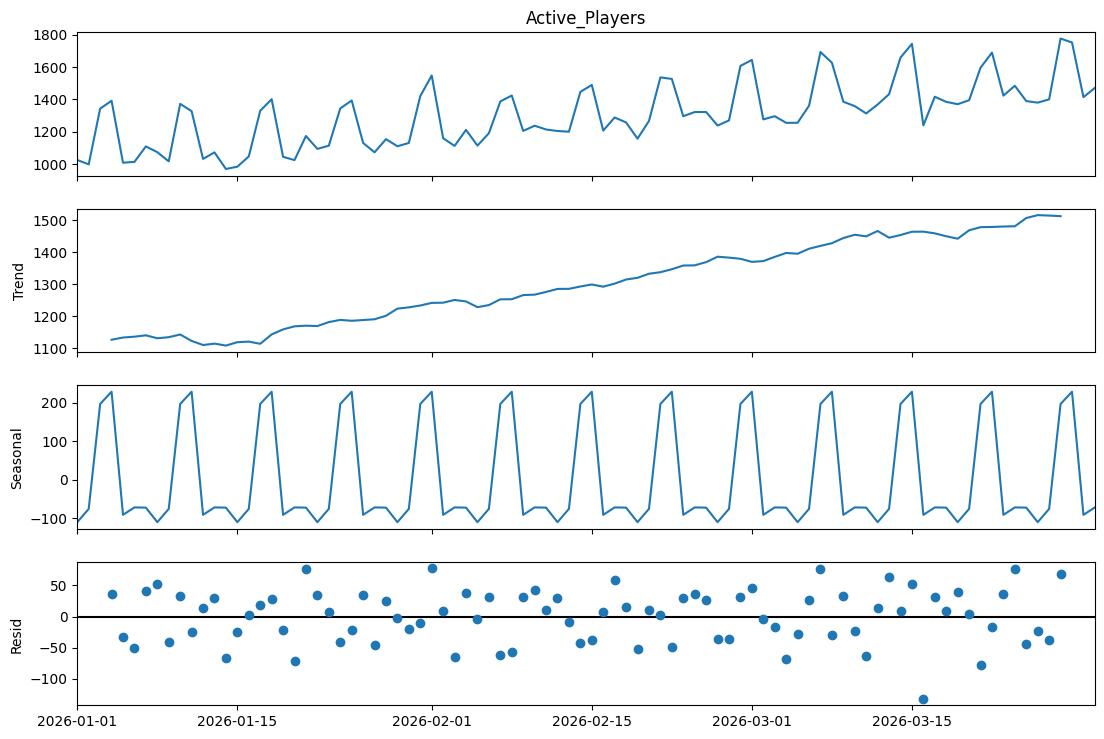

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Create a 90-day timeline (Daily data starting Jan 1st)
np.random.seed(42)
dates = pd.date_range(start='2026-01-01', periods=90, freq='D')

# Simulate daily active players: Base traffic + upward trend + weekly weekend spike + random noise
base_players = 1000
trend_slope = np.arange(90) * 5                                # Steady growth
weekend_spike = np.array([300 if d.dayofweek >= 5 else 0 for d in dates]) # Sat/Sun boost
noise = np.random.normal(scale=50, size=90)

player_counts = base_players + trend_slope + weekend_spike + noise

# 2. Build the Time Series DataFrame
df_time = pd.DataFrame({'Active_Players': player_counts}, index=dates)

print("--- ⏱️ Time Series Data Structure ---")
print(df_time.head(10)) # Look at the index column! It's formatted as dates.

# 3. Decompose the timeline into Trend, Seasonality, and Residuals
# We use a period of 7 because our pattern repeats every 7 days (weekly cycle)
decomposition = seasonal_decompose(df_time['Active_Players'], model='additive', period=7)

# 4. Plot the broken-down components visually
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()